# Experiment 05 — Carbon Price (7 Levels)

Does a higher carbon shadow price reroute mine-access roads away from forest?

Eight friction layers span the full range of plausible carbon prices, from the voluntary market to hypothetical extreme stress-test levels:

| Friction key | Carbon price | Label |
|---|---|---|
| `construction_only` | 0 USD/tCO₂e | Baseline |
| `carbon_low` | 5 USD/tCO₂e | Low |
| `carbon_central` | 40 USD/tCO₂e | Central |
| `carbon_high` | 90 USD/tCO₂e | High |
| `carbon_300` | 300 USD/tCO₂e | Very high |
| `carbon_930` | 930 USD/tCO₂e | Extreme |
| `carbon_1200` | 1,200 USD/tCO₂e | Extreme II |
| `carbon_1400` | 1,400 USD/tCO₂e | Extreme III |

Two spatial masks: **No mask** and **Protected areas** (no buffer).  
Mining scope: **Late + Early-stage mines (29)** only.

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from IPython.display import display

RESULTS_DIR  = Path('../model/results/impact-assessment/experiment_05_carbon_5lv')
FIGURES_DIR  = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# ── Carbon price levels ───────────────────────────────────────────────────────
FRICTION_ORDER = [
    'construction_only',
    'carbon_low',
    'carbon_central',
    'carbon_high',
    'carbon_300',
    'carbon_930',
    'carbon_1200',
    'carbon_1400',
]
FRICTION_LABELS = {
    'construction_only': 'Baseline (0)',
    'carbon_low':        'Low (5)',
    'carbon_central':    'Central (40)',
    'carbon_high':       'High (90)',
    'carbon_300':        'Very high (300)',
    'carbon_930':        'Extreme (930)',
    'carbon_1200':       'Extreme II (1,200)',
    'carbon_1400':       'Extreme III (1,400)',
}
CARBON_PRICES = {
    'construction_only': 0,
    'carbon_low':        5,
    'carbon_central':    40,
    'carbon_high':       90,
    'carbon_300':        300,
    'carbon_930':        930,
    'carbon_1200':       1200,
    'carbon_1400':       1400,
}
FRICTION_COLORS = {
    'construction_only': '#636363',
    'carbon_low':        '#c7e9c0',
    'carbon_central':    '#74c476',
    'carbon_high':       '#41ab5d',
    'carbon_300':        '#005a32',
    'carbon_930':        '#00441b',
    'carbon_1200':       '#762a83',
    'carbon_1400':       '#40004b',
}

# ── Mask metadata ─────────────────────────────────────────────────────────────
MASK_ORDER  = ['no_mask', 'protected_areas']
MASK_LABELS = {
    'no_mask':         'No mask',
    'protected_areas': 'Protected areas',
}
MASK_COLORS = {
    'no_mask':         '#2171b5',
    'protected_areas': '#d94801',
}
MASK_MARKERS = {
    'no_mask':         'o',
    'protected_areas': 's',
}

# ── Load CSVs ─────────────────────────────────────────────────────────────────
dfs = []
for fp in sorted(RESULTS_DIR.glob('*__assessment.csv')):
    df    = pd.read_csv(fp)
    parts = fp.stem.replace('__assessment', '').split('__')
    df['friction'] = '__'.join(parts[2:-2])
    df['mask']     = parts[-2]
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data['friction'] = pd.Categorical(data['friction'], FRICTION_ORDER, ordered=True)
data['mask']     = pd.Categorical(data['mask'],     MASK_ORDER,     ordered=True)
data = data.sort_values(['friction', 'mask']).reset_index(drop=True)

# ── Derived columns ────────────────────────────────────────────────────────────
data['carbon_price_usd']       = data['friction'].map(CARBON_PRICES)
data['construction_cost_musd'] = data['construction_cost_usd'] / 1e6
data['shadow_cost_musd']       = data['shadow_cost_usd']       / 1e6
data['total_cost_musd']        = data['construction_cost_musd'] + data['shadow_cost_musd']
data['defor_action_kha']       = data['defor_action_ha']        / 1e3
data['defor_upgrade_kha']      = data['defor_upgrade_ha']       / 1e3
data['defor_build_kha']        = data['defor_build_ha']         / 1e3
data['defor_direct_kha']       = data['defor_direct_ha']        / 1e3
data['defor_indirect_kha']     = data['defor_indirect_ha']      / 1e3
data['delta_fi_e6']            = data['frag_delta_frag_index']  * 1e6

print(f'Loaded {len(data)} scenarios × {data.shape[1]} columns')
print('Friction levels:', data['friction'].nunique(), '| Masks:', data['mask'].nunique())

preview_cols = ['friction', 'mask', 'total_km', 'construction_cost_musd',
                'shadow_cost_musd', 'defor_action_kha', 'defor_direct_kha',
                'defor_indirect_kha', 'frag_delta_n_patches', 'delta_fi_e6']
display(data[preview_cols].rename(columns={
    'friction': 'Friction', 'mask': 'Mask',
    'total_km': 'Total km',
    'construction_cost_musd': 'Constr. cost (M USD)',
    'shadow_cost_musd': 'Shadow cost (M USD)',
    'defor_action_kha': 'Defor. total (kha)',
    'defor_direct_kha': 'Direct (kha)',
    'defor_indirect_kha': 'Indirect (kha)',
    'frag_delta_n_patches': 'Δ patches',
    'delta_fi_e6': 'Δ FI (×10⁻⁶)',
}).style.format({
    'Total km': '{:.0f}',
    'Constr. cost (M USD)': '${:.1f}M',
    'Shadow cost (M USD)': '${:.1f}M',
    'Defor. total (kha)': '{:.2f}',
    'Direct (kha)': '{:.2f}',
    'Indirect (kha)': '{:.2f}',
    'Δ patches': '{:+.0f}',
    'Δ FI (×10⁻⁶)': '{:+.2f}',
}))

Loaded 16 scenarios × 95 columns
Friction levels: 8 | Masks: 2


,Friction,Mask,Total km,Constr. cost (M USD),Shadow cost (M USD),Defor. total (kha),Direct (kha),Indirect (kha),Δ patches,Δ FI (×10⁻⁶)
0,construction_only,no_mask,4275,$181.9M,$0.0M,69.76,1.36,68.41,+86,+2.94
1,construction_only,protected_areas,4524,$219.5M,$0.0M,74.53,1.48,73.05,+176,+5.85
2,carbon_low,no_mask,4275,$181.9M,$1.2M,69.76,1.36,68.41,+86,+2.94
3,carbon_low,protected_areas,4524,$219.4M,$1.3M,74.53,1.48,73.05,+176,+5.85
4,carbon_central,no_mask,4276,$181.6M,$8.9M,69.56,1.32,68.24,+88,+3.00
5,carbon_central,protected_areas,4525,$219.3M,$9.6M,74.32,1.44,72.88,+179,+5.94
6,carbon_high,no_mask,4277,$182.1M,$19.8M,69.60,1.32,68.28,+88,+3.00
7,carbon_high,protected_areas,4526,$219.8M,$21.4M,74.37,1.44,72.93,+179,+5.94
8,carbon_300,no_mask,4344,$183.1M,$58.8M,70.71,1.29,69.42,+88,+3.01
9,carbon_300,protected_areas,4548,$222.0M,$63.1M,76.63,1.47,75.16,+179,+5.96


## 1. Effect of Carbon Price — Line Plots

Each line = one spatial mask. X-axis = carbon price (USD/tCO₂e) on a log scale.
If carbon pricing reroutes roads, construction cost and deforestation should decrease as price rises.

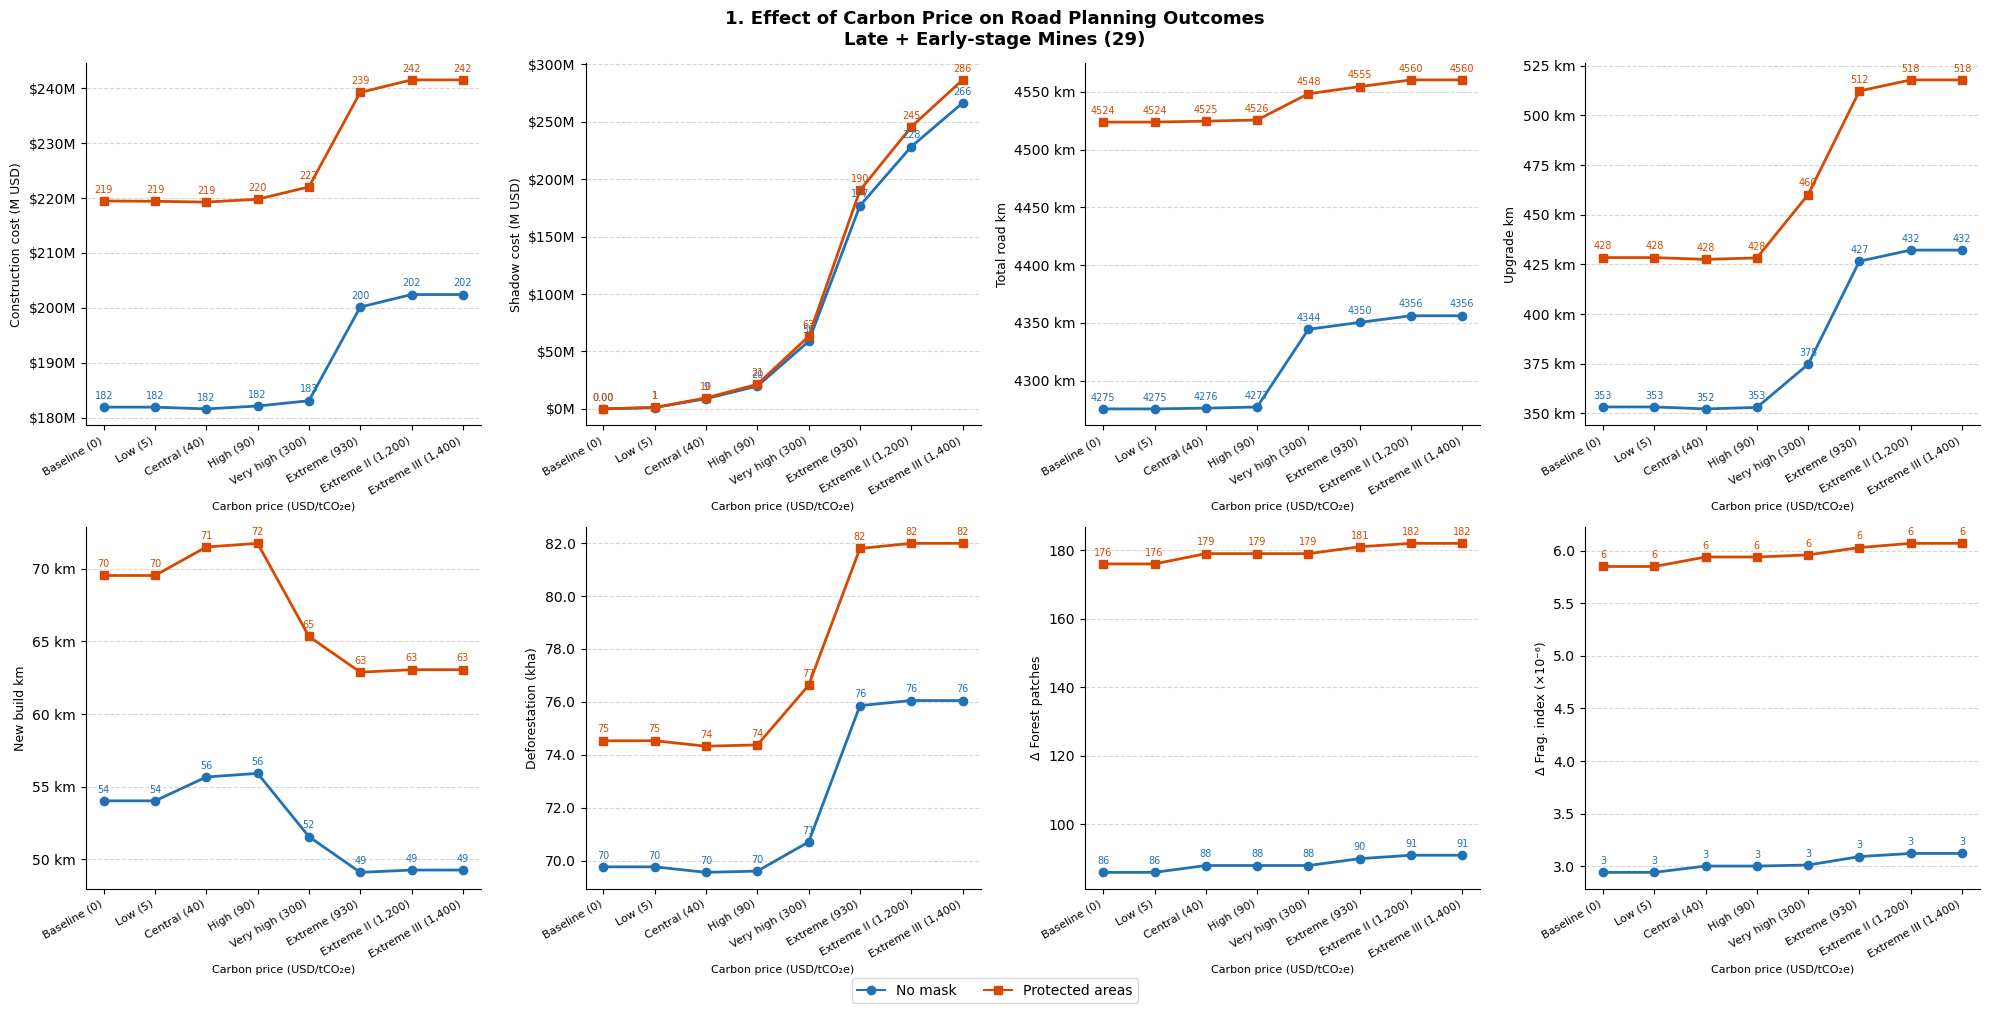

In [9]:
LINE_METRICS = [
    ('construction_cost_musd', 'Construction cost (M USD)', lambda v, _: f'${v:.0f}M'),
    ('shadow_cost_musd',       'Shadow cost (M USD)',       lambda v, _: f'${v:.0f}M'),
    ('total_km',               'Total road km',             lambda v, _: f'{v:.0f} km'),
    ('unpaved_km',             'Upgrade km',                lambda v, _: f'{v:.0f} km'),
    ('to_be_built_km',         'New build km',              lambda v, _: f'{v:.0f} km'),
    ('defor_action_kha',       'Deforestation (kha)',        lambda v, _: f'{v:.1f}'),
    ('frag_delta_n_patches',   'Δ Forest patches',          None),
    ('delta_fi_e6',            'Δ Frag. index (×10⁻⁶)',     None),
]

x_vals   = [CARBON_PRICES[f] for f in FRICTION_ORDER]
x_labels = [FRICTION_LABELS[f] for f in FRICTION_ORDER]

n_cols = 4
n_rows = int(np.ceil(len(LINE_METRICS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
fig.suptitle(
    '1. Effect of Carbon Price on Road Planning Outcomes\n'
    'Late + Early-stage Mines (29)',
    fontsize=13, fontweight='bold'
)
axes_flat = axes.flatten()

for i, (col, ylabel, fmt) in enumerate(LINE_METRICS):
    ax = axes_flat[i]
    for mask in MASK_ORDER:
        sub  = data[data['mask'] == mask].set_index('friction').reindex(FRICTION_ORDER)
        vals = sub[col].values
        ax.plot(range(len(FRICTION_ORDER)), vals,
                color=MASK_COLORS[mask],
                marker=MASK_MARKERS[mask],
                markersize=6, linewidth=2,
                label=MASK_LABELS[mask])
        for xi, v in enumerate(vals):
            if not np.isnan(v):
                ax.annotate(
                    f'{v:.0f}' if abs(v) >= 1 else f'{v:.2f}',
                    xy=(xi, v), xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=7, color=MASK_COLORS[mask],
                )

    ax.set_xticks(range(len(FRICTION_ORDER)))
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('Carbon price (USD/tCO₂e)', fontsize=8)
    if fmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Hide unused axes
for j in range(len(LINE_METRICS), len(axes_flat)):
    axes_flat[j].set_visible(False)

handles = [mlines.Line2D([], [], color=MASK_COLORS[m], marker=MASK_MARKERS[m],
                         markersize=6, label=MASK_LABELS[m])
           for m in MASK_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_carbon_price_line_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Cost Breakdown by Carbon Price Level

Stacked bars: construction cost (solid) + shadow cost (semi-transparent).  
Two groups: No mask vs Protected areas.

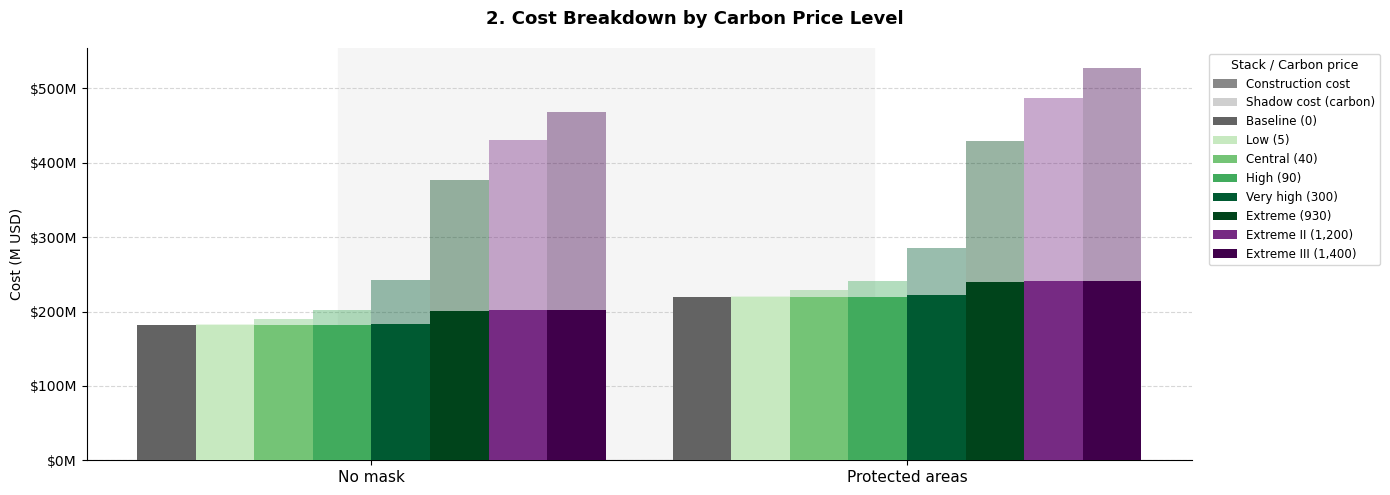

In [10]:
n_fricts     = len(FRICTION_ORDER)
n_masks      = len(MASK_ORDER)
bar_w        = 0.35
group_gap    = 0.4
group_width  = n_fricts * bar_w + group_gap
group_starts = np.arange(n_masks) * group_width
offsets      = np.arange(n_fricts) * bar_w - (n_fricts - 1) * bar_w / 2

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('2. Cost Breakdown by Carbon Price Level', fontsize=13, fontweight='bold')

for gi in range(n_masks):
    if gi % 2 == 0:
        ax.axvspan(group_starts[gi] - group_gap / 2,
                   group_starts[gi] + n_fricts * bar_w + group_gap / 2,
                   color='#f5f5f5', zorder=0)

for fi, friction in enumerate(FRICTION_ORDER):
    sub      = data[data['friction'] == friction].set_index('mask').reindex(MASK_ORDER)
    xs       = group_starts + offsets[fi]
    bot_vals = sub['construction_cost_musd'].values
    top_vals = sub['shadow_cost_musd'].values
    ax.bar(xs, bot_vals, width=bar_w,
           color=FRICTION_COLORS[friction],
           label=FRICTION_LABELS[friction],
           zorder=3, edgecolor='none')
    ax.bar(xs, top_vals, bottom=bot_vals, width=bar_w,
           color=FRICTION_COLORS[friction], alpha=0.4,
           zorder=3, edgecolor='none')

ax.set_xticks(group_starts)
ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=11)
ax.set_ylabel('Cost (M USD)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

stack_handles = [
    mpatches.Patch(facecolor='#888888', alpha=1.0, label='Construction cost'),
    mpatches.Patch(facecolor='#888888', alpha=0.4, label='Shadow cost (carbon)'),
]
fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                for f in FRICTION_ORDER]
ax.legend(handles=stack_handles + fric_handles,
          title='Stack / Carbon price',
          fontsize=8.5, title_fontsize=9, frameon=True,
          loc='upper left', bbox_to_anchor=(1.01, 1), ncol=1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_cost_by_carbon_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Deforestation & Fragmentation by Carbon Price Level

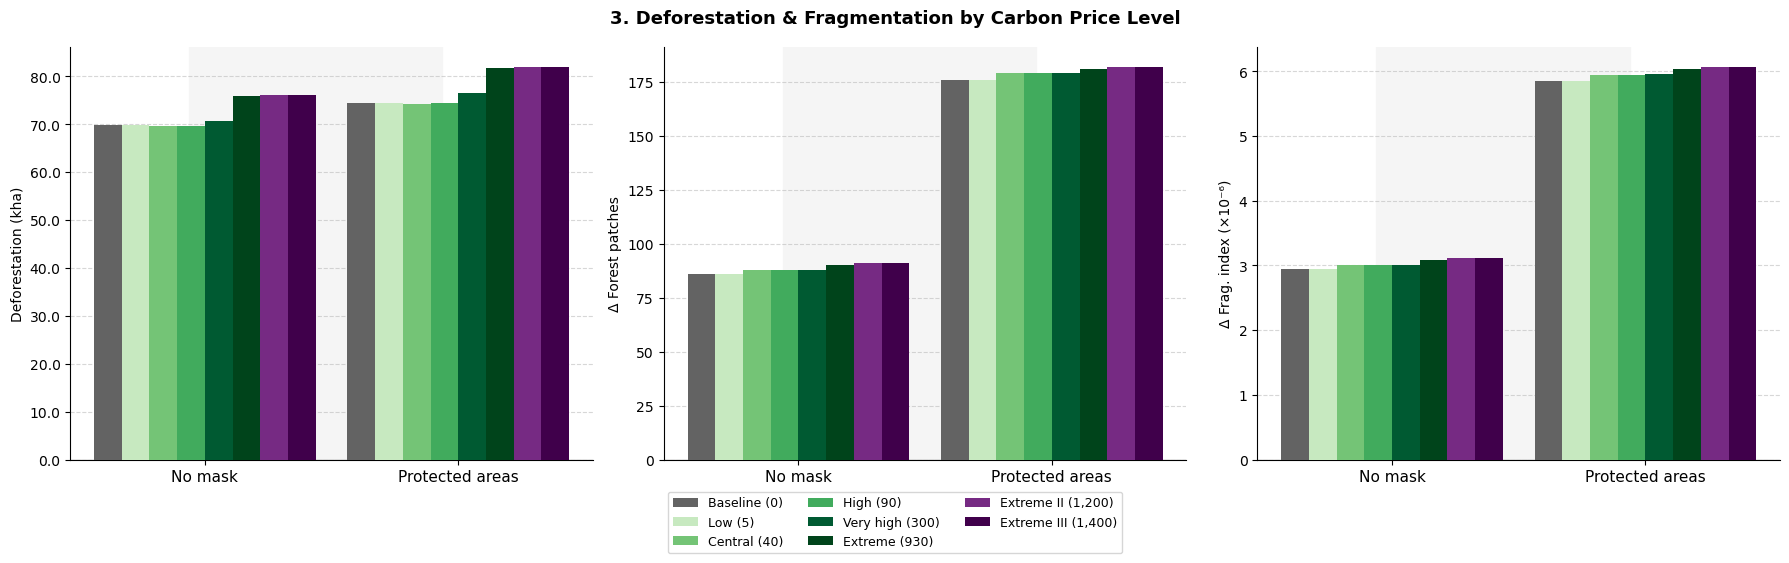

In [11]:
ENV_METRICS = [
    ('defor_action_kha',     'Deforestation (kha)',        lambda v, _: f'{v:.1f}'),
    ('frag_delta_n_patches', 'Δ Forest patches',           None),
    ('delta_fi_e6',          'Δ Frag. index (×10⁻⁶)',      None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3. Deforestation & Fragmentation by Carbon Price Level', fontsize=13, fontweight='bold')

for ax, (col, ylabel, fmt) in zip(axes, ENV_METRICS):
    for gi in range(n_masks):
        if gi % 2 == 0:
            ax.axvspan(group_starts[gi] - group_gap / 2,
                       group_starts[gi] + n_fricts * bar_w + group_gap / 2,
                       color='#f5f5f5', zorder=0)

    for fi, friction in enumerate(FRICTION_ORDER):
        sub  = data[data['friction'] == friction].set_index('mask').reindex(MASK_ORDER)
        xs   = group_starts + offsets[fi]
        vals = sub[col].values
        ax.bar(xs, vals, width=bar_w,
               color=FRICTION_COLORS[friction],
               label=FRICTION_LABELS[friction],
               zorder=3, edgecolor='none')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(group_starts)
    ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    if fmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                for f in FRICTION_ORDER]
fig.legend(handles=fric_handles, loc='lower center', ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_env_by_carbon_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Deforestation Breakdown — Direct vs. Indirect

**Direct** deforestation = forest cleared within the road footprint itself.  
**Indirect** deforestation = additional forest loss in the surrounding area (edge effects, access-induced clearing).

Stacked bars: direct (solid) + indirect (semi-transparent on top).  
Both panels share the same y-axis scale for comparison across masks.

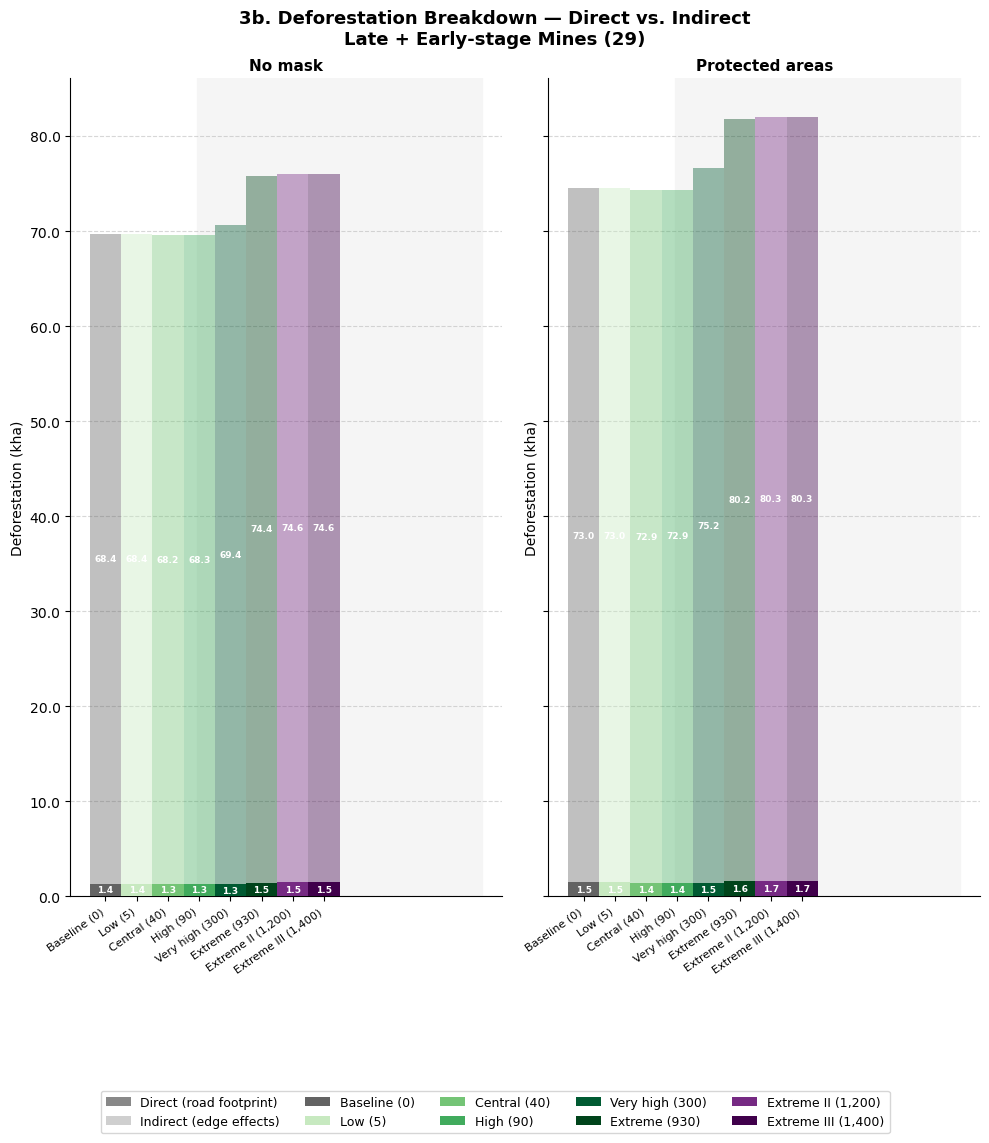

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
fig.suptitle(
    '3b. Deforestation Breakdown — Direct vs. Indirect\n'
    'Late + Early-stage Mines (29)',
    fontsize=13, fontweight='bold'
)

for ax, mask in zip(axes, MASK_ORDER):
    for gi in range(1):  # single group per panel
        ax.axvspan(-group_gap / 2,
                   n_fricts * bar_w + group_gap / 2,
                   color='#f5f5f5', zorder=0)

    single_offsets = np.arange(n_fricts) * bar_w - (n_fricts - 1) * bar_w / 2

    for fi, friction in enumerate(FRICTION_ORDER):
        row      = data[(data['friction'] == friction) & (data['mask'] == mask)]
        direct   = row['defor_direct_kha'].values[0]   if not row.empty else 0.0
        indirect = row['defor_indirect_kha'].values[0] if not row.empty else 0.0
        x        = single_offsets[fi]

        ax.bar(x, direct, width=bar_w,
               color=FRICTION_COLORS[friction],
               label=FRICTION_LABELS[friction],
               zorder=3, edgecolor='none')
        ax.bar(x, indirect, bottom=direct, width=bar_w,
               color=FRICTION_COLORS[friction], alpha=0.4,
               zorder=3, edgecolor='none')

        # Value labels on each segment
        if direct > 0.05:
            ax.text(x, direct / 2, f'{direct:.1f}',
                    ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')
        if indirect > 0.05:
            ax.text(x, direct + indirect / 2, f'{indirect:.1f}',
                    ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')

    ax.set_xticks(single_offsets)
    ax.set_xticklabels([FRICTION_LABELS[f] for f in FRICTION_ORDER],
                       rotation=35, ha='right', fontsize=8)
    ax.set_title(MASK_LABELS[mask], fontweight='bold', fontsize=11)
    ax.set_ylabel('Deforestation (kha)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

stack_handles = [
    mpatches.Patch(facecolor='#888888', alpha=1.0, label='Direct (road footprint)'),
    mpatches.Patch(facecolor='#888888', alpha=0.4, label='Indirect (edge effects)'),
]
fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                for f in FRICTION_ORDER]
fig.legend(handles=stack_handles + fric_handles,
           loc='lower center', ncol=5, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3b_defor_breakdown_direct_indirect.png', dpi=150, bbox_inches='tight')
plt.show()

## 3c. Direct Deforestation by Carbon Price Level

Road-footprint deforestation only — forest cleared within the physical road corridor itself.  
This isolates the routing decision from indirect land-use effects, showing whether carbon pricing changes *where* the road is built.

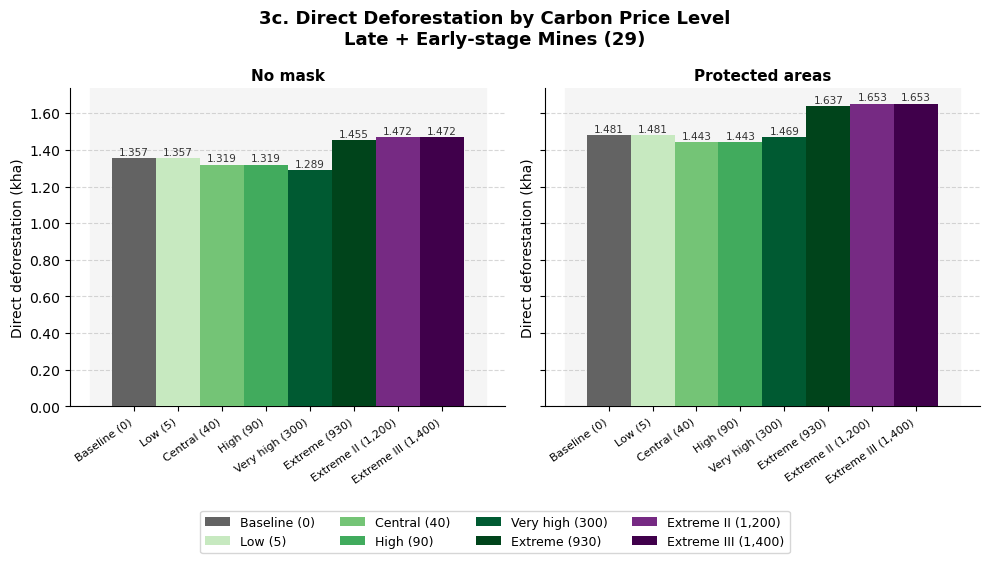

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle(
    '3c. Direct Deforestation by Carbon Price Level\n'
    'Late + Early-stage Mines (29)',
    fontsize=13, fontweight='bold'
)

single_offsets = np.arange(n_fricts) * bar_w - (n_fricts - 1) * bar_w / 2

for ax, mask in zip(axes, MASK_ORDER):
    ax.axvspan(single_offsets[0] - bar_w, single_offsets[-1] + bar_w,
               color='#f5f5f5', zorder=0)

    for fi, friction in enumerate(FRICTION_ORDER):
        row  = data[(data['friction'] == friction) & (data['mask'] == mask)]
        val  = row['defor_direct_kha'].values[0] if not row.empty else 0.0
        x    = single_offsets[fi]

        bar = ax.bar(x, val, width=bar_w,
                     color=FRICTION_COLORS[friction],
                     label=FRICTION_LABELS[friction],
                     zorder=3, edgecolor='none')

        ax.text(x, val + 0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=7.5, color='#333333')

    ax.set_xticks(single_offsets)
    ax.set_xticklabels([FRICTION_LABELS[f] for f in FRICTION_ORDER],
                       rotation=35, ha='right', fontsize=8)
    ax.set_title(MASK_LABELS[mask], fontweight='bold', fontsize=11)
    ax.set_ylabel('Direct deforestation (kha)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                for f in FRICTION_ORDER]
fig.legend(handles=fric_handles, loc='lower center', ncol=4, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3c_defor_direct.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Road km by Carbon Price Level

Stacked: upgrade km (solid) + new build km (semi-transparent).  
If carbon pricing shifts routing, new build km should decrease and upgrade km may increase.

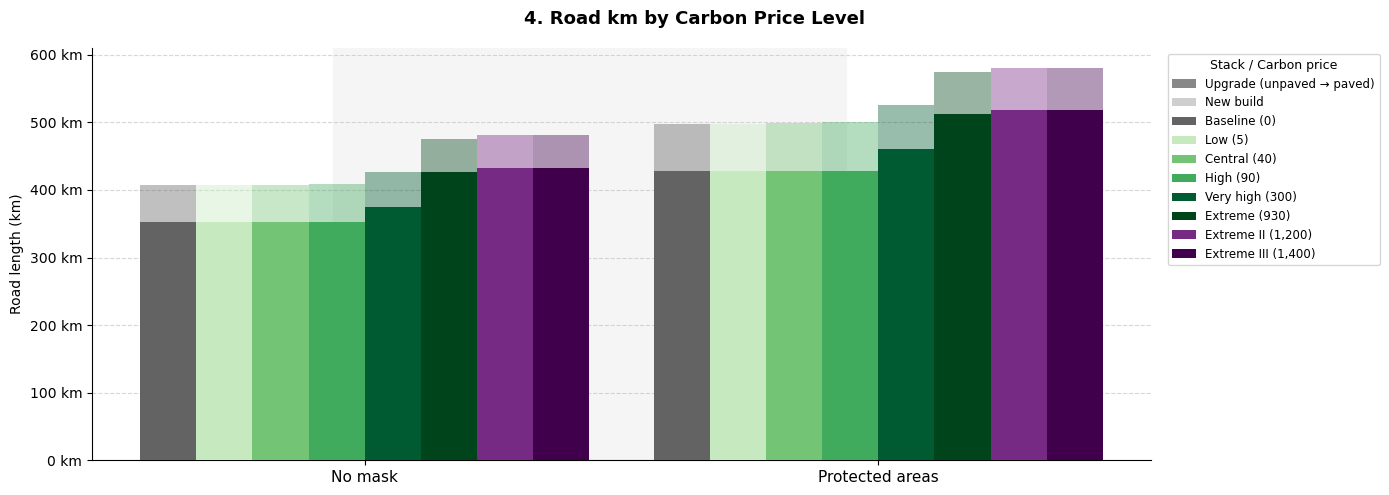

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('4. Road km by Carbon Price Level', fontsize=13, fontweight='bold')

for gi in range(n_masks):
    if gi % 2 == 0:
        ax.axvspan(group_starts[gi] - group_gap / 2,
                   group_starts[gi] + n_fricts * bar_w + group_gap / 2,
                   color='#f5f5f5', zorder=0)

for fi, friction in enumerate(FRICTION_ORDER):
    sub      = data[data['friction'] == friction].set_index('mask').reindex(MASK_ORDER)
    xs       = group_starts + offsets[fi]
    bot_vals = sub['unpaved_km'].values
    top_vals = sub['to_be_built_km'].values
    ax.bar(xs, bot_vals, width=bar_w,
           color=FRICTION_COLORS[friction],
           label=FRICTION_LABELS[friction],
           zorder=3, edgecolor='none')
    ax.bar(xs, top_vals, bottom=bot_vals, width=bar_w,
           color=FRICTION_COLORS[friction], alpha=0.4,
           zorder=3, edgecolor='none')

ax.set_xticks(group_starts)
ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=11)
ax.set_ylabel('Road length (km)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f} km'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

stack_handles = [
    mpatches.Patch(facecolor='#888888', alpha=1.0, label='Upgrade (unpaved → paved)'),
    mpatches.Patch(facecolor='#888888', alpha=0.4, label='New build'),
]
fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                for f in FRICTION_ORDER]
ax.legend(handles=stack_handles + fric_handles,
          title='Stack / Carbon price',
          fontsize=8.5, title_fontsize=9, frameon=True,
          loc='upper left', bbox_to_anchor=(1.01, 1), ncol=1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_road_km_by_carbon_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Forest Patch Size Distribution — Delta

Change in number of patches (after − before) per size class.  
Positive = new smaller patches created; negative = large patches lost.  
Two subplots: No mask and Protected areas.

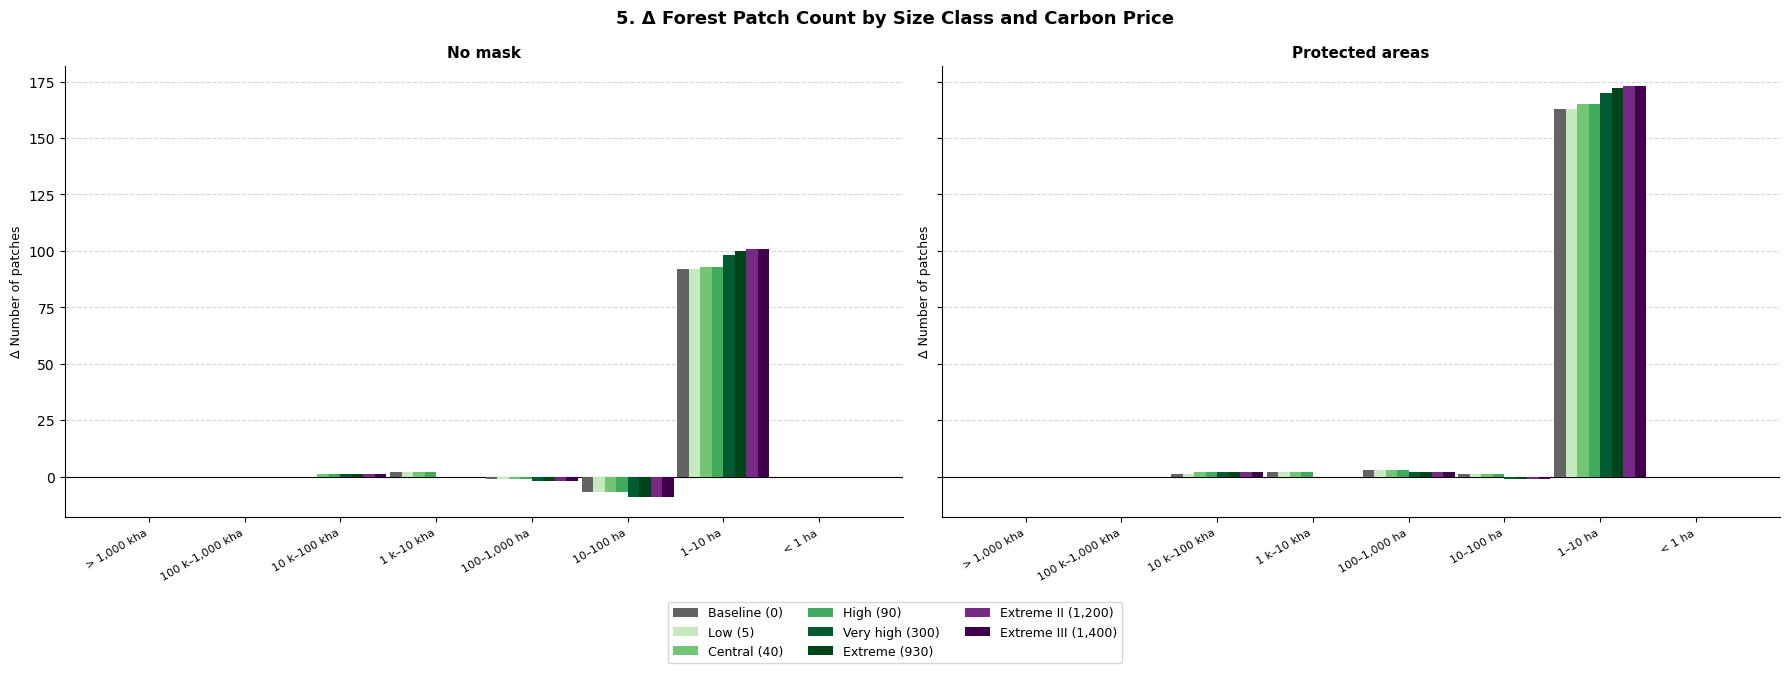

In [14]:
SIZE_CLASSES = [
    ('frag_patch_size_dis_delta_gt1000kha_n',  '> 1,000 kha'),
    ('frag_patch_size_dis_delta_100k_1000kha_n', '100 k–1,000 kha'),
    ('frag_patch_size_dis_delta_10k_100kha_n',   '10 k–100 kha'),
    ('frag_patch_size_dis_delta_1k_10kha_n',     '1 k–10 kha'),
    ('frag_patch_size_dis_delta_100_1kha_n',     '100–1,000 ha'),
    ('frag_patch_size_dis_delta_10_100ha_n',     '10–100 ha'),
    ('frag_patch_size_dis_delta_1_10ha_n',       '1–10 ha'),
    ('frag_patch_size_dis_delta_lt1ha_n',        '< 1 ha'),
]
size_labels = [s[1] for s in SIZE_CLASSES]
size_cols   = [s[0] for s in SIZE_CLASSES]

x_pos   = np.arange(len(SIZE_CLASSES))
bar_w2  = 0.12
offsets2 = np.arange(len(FRICTION_ORDER)) * bar_w2 - (len(FRICTION_ORDER) - 1) * bar_w2 / 2

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle('5. Δ Forest Patch Count by Size Class and Carbon Price', fontsize=13, fontweight='bold')

for ax, mask in zip(axes, MASK_ORDER):
    subset = data[data['mask'] == mask]
    for fi, friction in enumerate(FRICTION_ORDER):
        row  = subset[subset['friction'] == friction]
        vals = row[size_cols].values.flatten() if not row.empty else np.zeros(len(SIZE_CLASSES))
        ax.bar(x_pos + offsets2[fi], vals, width=bar_w2,
               color=FRICTION_COLORS[friction],
               label=FRICTION_LABELS[friction],
               zorder=3, edgecolor='none')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(size_labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(MASK_LABELS[mask], fontweight='bold', fontsize=11)
    ax.set_ylabel('Δ Number of patches', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                for f in FRICTION_ORDER]
fig.legend(handles=fric_handles, loc='lower center', ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_delta_patch_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Spatial Map — Carbon Price Effect

Generated paths at each carbon price level under **No mask**.  
Blue = upgrade (unpaved → paved); red = new build; gray = existing paved roads.

Mines: 29 | Paved roads: 21919
Loaded 8 action-road layers, 8 full-path layers


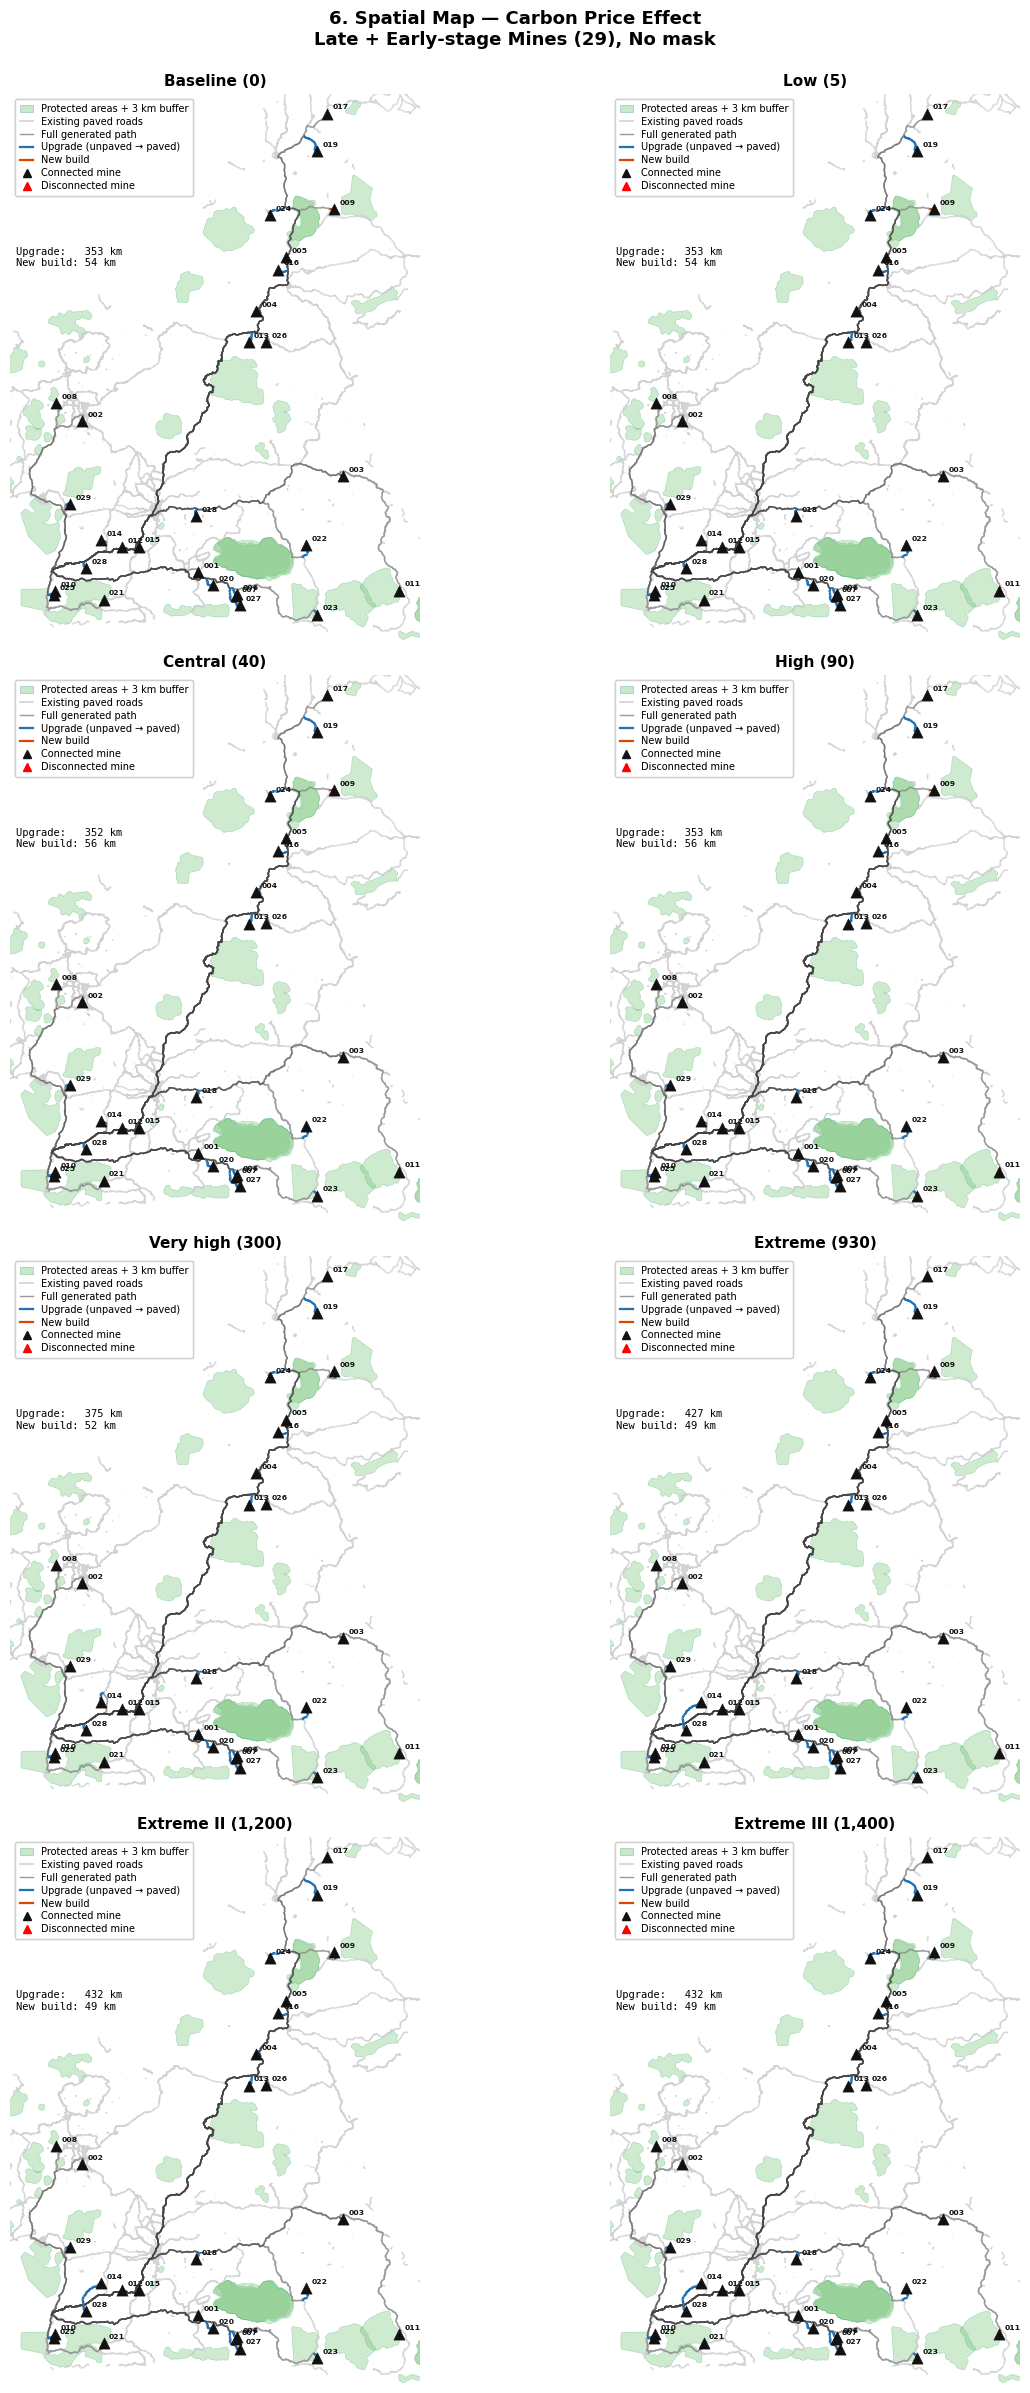

In [15]:
import geopandas as gpd

ROADS_FP  = Path('../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg')
MINES_FP  = Path('../data/output/cmr-mine-locations/all_mines_with_id.csv')
PA_FP     = Path('../data/output/processed-protected-areas/with-buffer/cmr-protected-areas__buffer3km.gpkg')

# Paths come from different source folders depending on friction
PATHS_DIRS = {
    'construction_only': Path('../model/results/least-cost-paths/experiment_04_h1'),
    'carbon_low':        Path('../model/results/least-cost-paths/experiment_04_h1'),
    'carbon_central':    Path('../model/results/least-cost-paths/experiment_04_h1'),
    'carbon_high':       Path('../model/results/least-cost-paths/experiment_04_h1'),
    'carbon_300':        Path('../model/results/least-cost-paths/experiment_04_additional'),
    'carbon_930':        Path('../model/results/least-cost-paths/experiment_04_additional2'),
    'carbon_1200':       Path('../model/results/least-cost-paths/experiment_04_additional3'),
    'carbon_1400':       Path('../model/results/least-cost-paths/experiment_04_additional3'),
}

FOCAL_MINING = 'late_and_early_stage'
FOCAL_MASK   = 'no_mask'

paved_roads     = gpd.read_file(ROADS_FP).query("liu_surface == 'paved'").to_crs('EPSG:4326')
protected_areas = gpd.read_file(PA_FP).to_crs('EPSG:4326')
mines_df        = pd.read_csv(MINES_FP)
mines           = mines_df[mines_df['DEV_STAGE_AGGREGATED_SNL'].isin(['Late-stage', 'Early-stage'])].copy()
print(f'Mines: {len(mines)} | Paved roads: {len(paved_roads)}')

# Load action roads and full paths
action_gdfs = {}
path_gdfs   = {}
for friction in FRICTION_ORDER:
    stem    = f'{FOCAL_MINING}__kribi__{friction}__{FOCAL_MASK}__ds1'
    act_fp  = RESULTS_DIR / f'{stem}__action_roads.gpkg'
    path_fp = PATHS_DIRS[friction] / f'{stem}.gpkg'
    if act_fp.exists():
        action_gdfs[friction] = gpd.read_file(act_fp)
    if path_fp.exists():
        path_gdfs[friction] = gpd.read_file(path_fp)

print(f'Loaded {len(action_gdfs)} action-road layers, {len(path_gdfs)} full-path layers')

# Bounding box
all_geom = pd.concat(path_gdfs.values())
minx = all_geom.geometry.total_bounds[0] - 0.3
miny = all_geom.geometry.total_bounds[1] - 0.3
maxx = all_geom.geometry.total_bounds[2] + 0.3
maxy = all_geom.geometry.total_bounds[3] + 0.3

legend_handles = [
    mpatches.Patch(facecolor='#74c476', alpha=0.35, edgecolor='#2ca25f',
                   linewidth=0.6, label='Protected areas + 3 km buffer'),
    mlines.Line2D([], [], color='#d3d3d3', linewidth=1.2, label='Existing paved roads'),
    mlines.Line2D([], [], color='#444444', linewidth=1.0, alpha=0.5, label='Full generated path'),
    mlines.Line2D([], [], color='#2171b5', linewidth=1.6, label='Upgrade (unpaved → paved)'),
    mlines.Line2D([], [], color='#d94801', linewidth=1.6, label='New build'),
    mlines.Line2D([], [], color='#111111', marker='^', markersize=6,
                  linestyle='None', label='Connected mine'),
    mlines.Line2D([], [], color='red',     marker='^', markersize=6,
                  linestyle='None', label='Disconnected mine'),
]

n_frictions = len(FRICTION_ORDER)   # 8
n_cols = 2
n_rows = n_frictions // n_cols      # 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 6))
fig.suptitle(
    f'6. Spatial Map — Carbon Price Effect\n'
    f'Late + Early-stage Mines (29), No mask',
    fontsize=13, fontweight='bold', y=0.995,
)

for idx, friction in enumerate(FRICTION_ORDER):
    r, c = divmod(idx, n_cols)
    ax   = axes[r][c]

    protected_areas.plot(ax=ax, color='#74c476', alpha=0.35,
                         edgecolor='#2ca25f', linewidth=0.4, zorder=0)
    paved_roads.plot(ax=ax, color='#d3d3d3', linewidth=1.0, zorder=1)

    full_path = path_gdfs.get(friction)
    if full_path is not None:
        full_path.plot(ax=ax, color='#444444', linewidth=1.0, alpha=0.4, zorder=2)

    gdf = action_gdfs.get(friction)
    if gdf is not None:
        upgrades   = gdf[gdf['action_needed'] == 'upgrade']
        new_builds = gdf[gdf['action_needed'] == 'build']
        if not upgrades.empty:   upgrades.plot(ax=ax,   color='#2171b5', linewidth=1.6, zorder=3)
        if not new_builds.empty: new_builds.plot(ax=ax, color='#d94801', linewidth=1.6, zorder=3)

    connected_ids = set(full_path['mine_id']) if full_path is not None else set()
    connected_m   = mines[mines['ID'].isin(connected_ids)]
    disco_m       = mines[~mines['ID'].isin(connected_ids)]

    if not connected_m.empty:
        ax.scatter(connected_m['LONGITUDE'], connected_m['LATITUDE'],
                   marker='^', s=65, color='#111111', edgecolors='#111111',
                   linewidths=0.4, zorder=5)
    if not disco_m.empty:
        ax.scatter(disco_m['LONGITUDE'], disco_m['LATITUDE'],
                   marker='^', s=65, color='red', edgecolors='#880000',
                   linewidths=0.4, zorder=5)

    for _, m_row in mines.iterrows():
        short_id  = m_row['ID'].replace('cmr_', '')
        label_col = '#880000' if m_row['ID'] not in connected_ids else '#111111'
        ax.annotate(short_id,
                    xy=(m_row['LONGITUDE'], m_row['LATITUDE']),
                    xytext=(4, 3), textcoords='offset points',
                    fontsize=5.5, color=label_col, zorder=6, fontweight='bold')

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_title(FRICTION_LABELS[friction], fontweight='bold', fontsize=11)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    leg = ax.legend(
        handles=legend_handles,
        loc='upper left', fontsize=7, framealpha=0.88,
        handlelength=1.4, borderpad=0.5, labelspacing=0.3,
    )
    ax.add_artist(leg)

    row_stats  = data[(data['friction'] == friction) & (data['mask'] == FOCAL_MASK)]
    upgrade_km = row_stats['unpaved_km'].values[0]     if not row_stats.empty else float('nan')
    build_km   = row_stats['to_be_built_km'].values[0] if not row_stats.empty else float('nan')
    ax.text(
        0.015, 0.72,
        f'Upgrade:   {upgrade_km:.0f} km\nNew build: {build_km:.0f} km',
        transform=ax.transAxes, fontsize=7.5, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.82, edgecolor='none'),
    )

plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.savefig(FIGURES_DIR / 'fig6_spatial_no_mask.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Zoomed Action Roads — Selected Mines

One figure per mine; 4 × 2 grid of subplots (one per carbon price level).  
Only the action road segment for that specific mine is shown, filtered by `mine_id`.  
Zoom extent is computed from the bounding box of that mine's action roads across all scenarios.

Requires cell 6 (spatial map) to be run first — reuses `action_gdfs`, `path_gdfs`, `paved_roads`, `protected_areas`, `mines`.

Saved: fig7_zoom_cmr_016.png


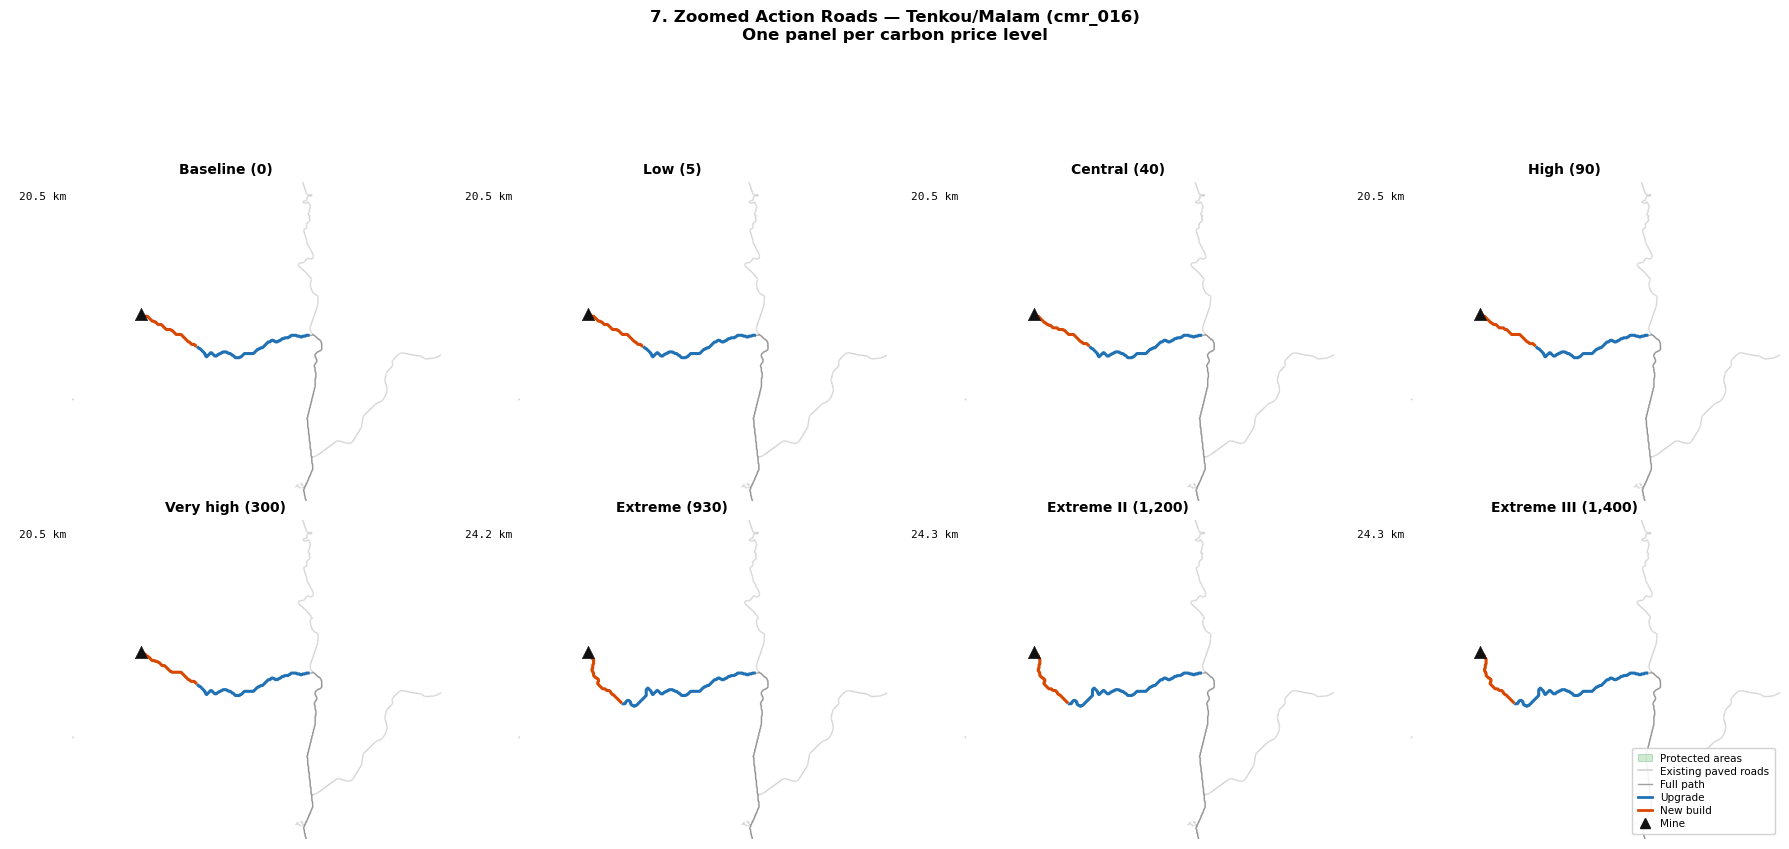

Saved: fig7_zoom_cmr_009.png


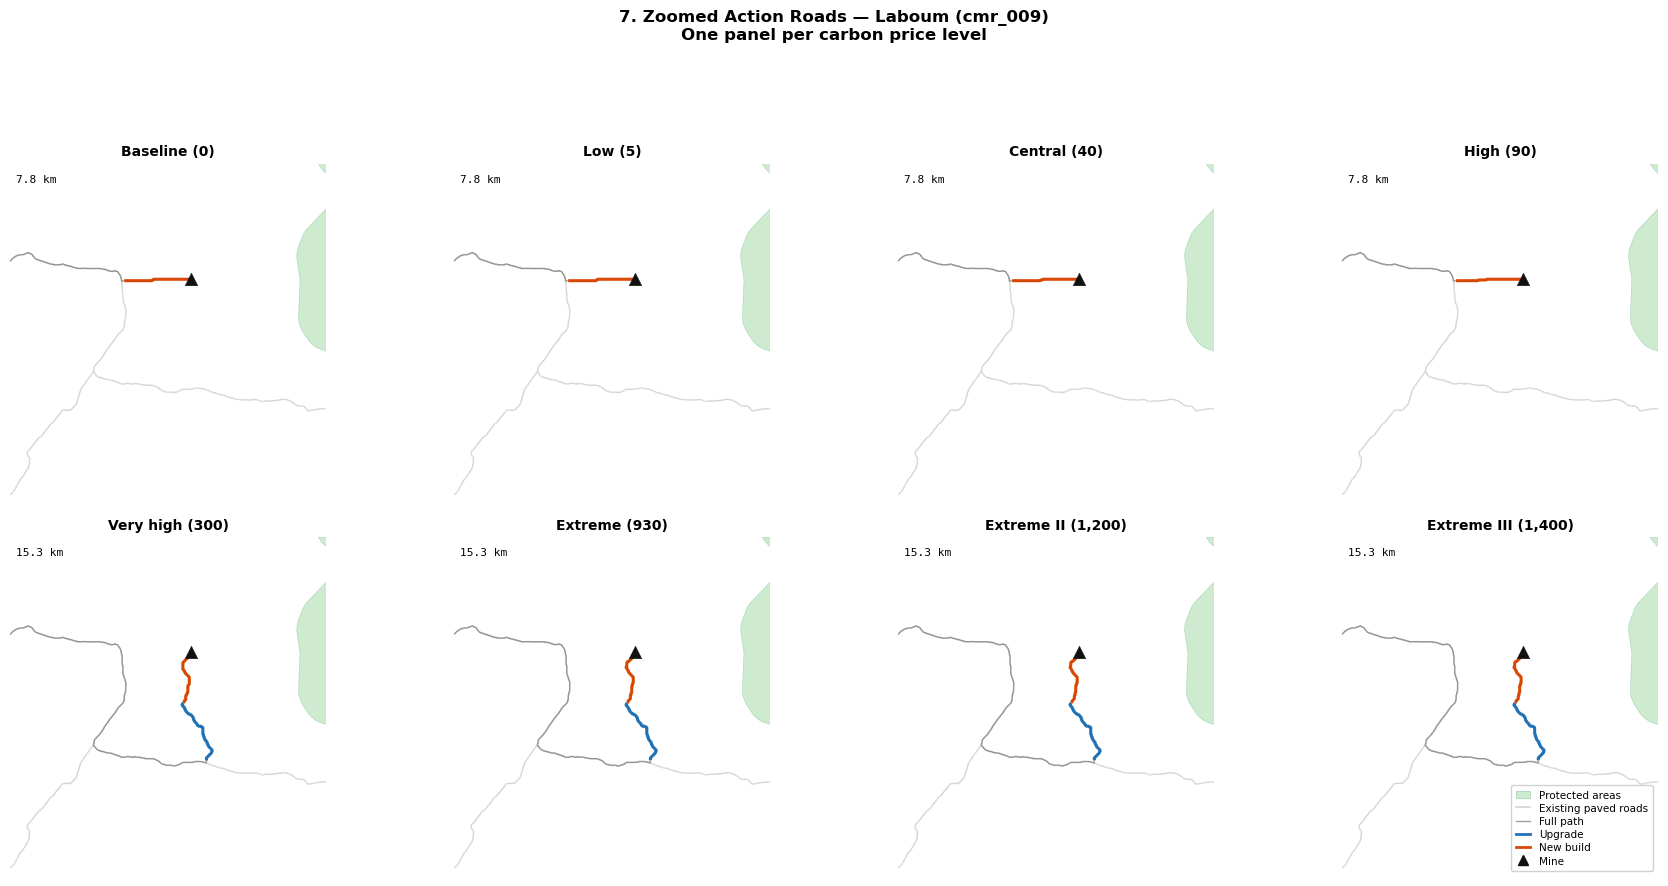

Saved: fig7_zoom_cmr_013.png


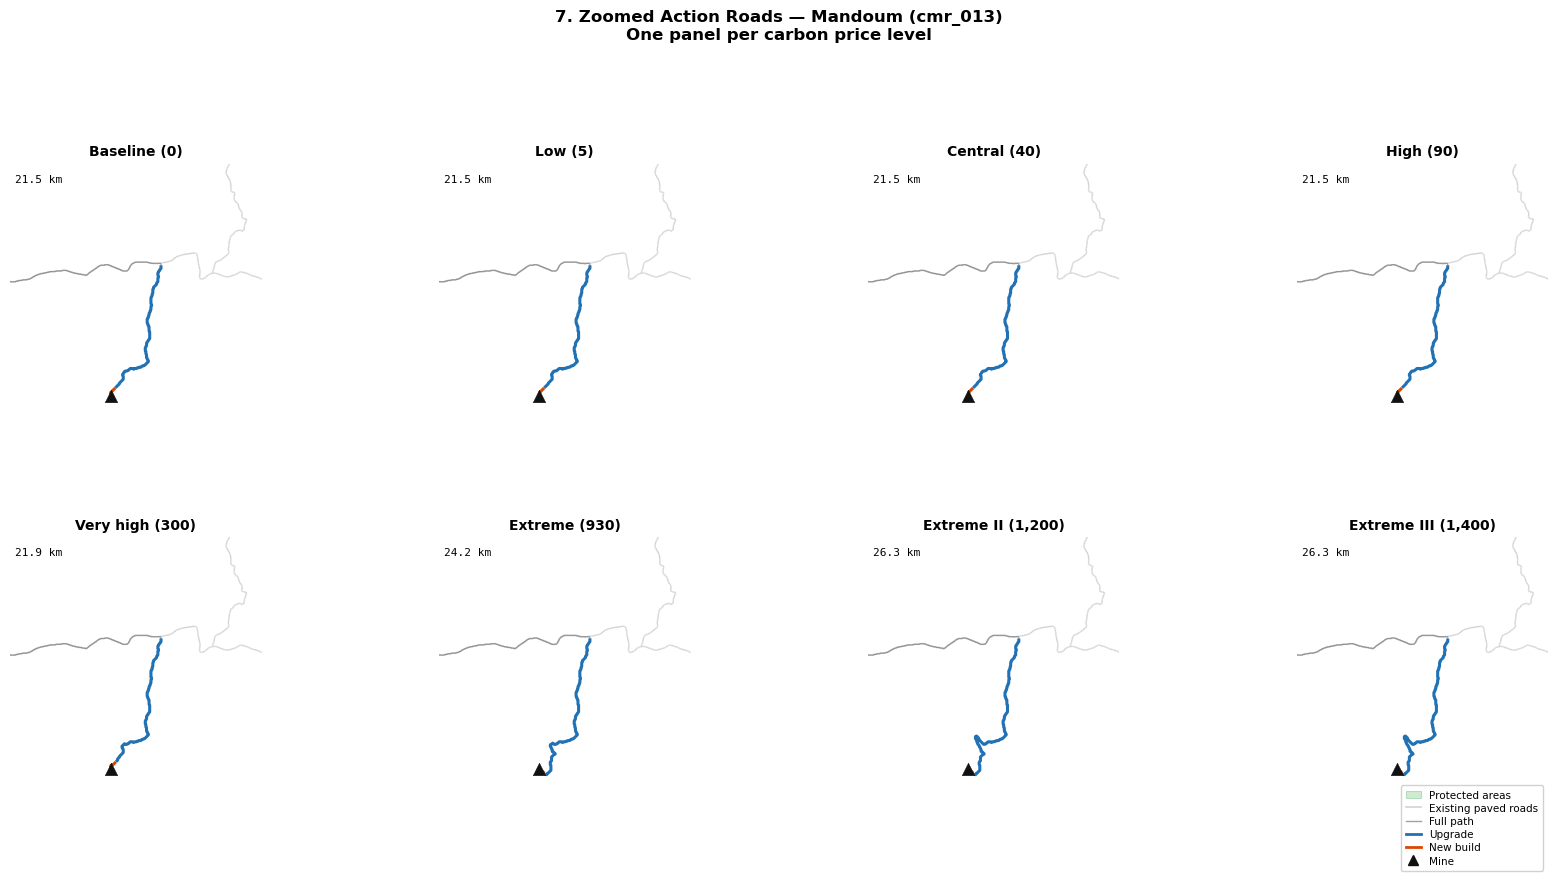

Saved: fig7_zoom_cmr_014.png


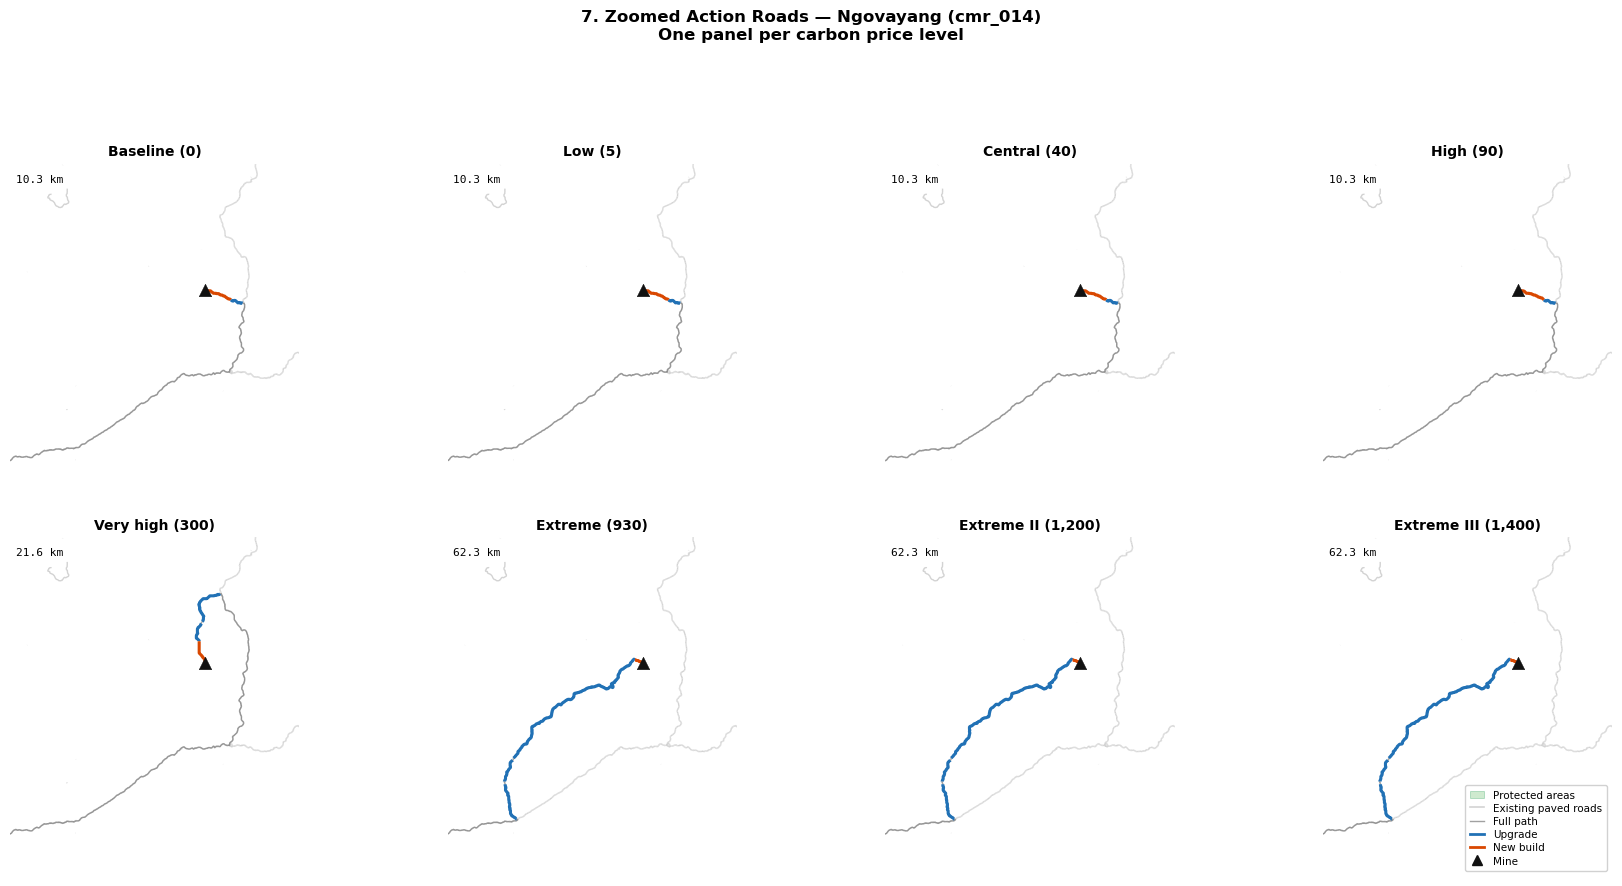

Saved: fig7_zoom_cmr_012.png


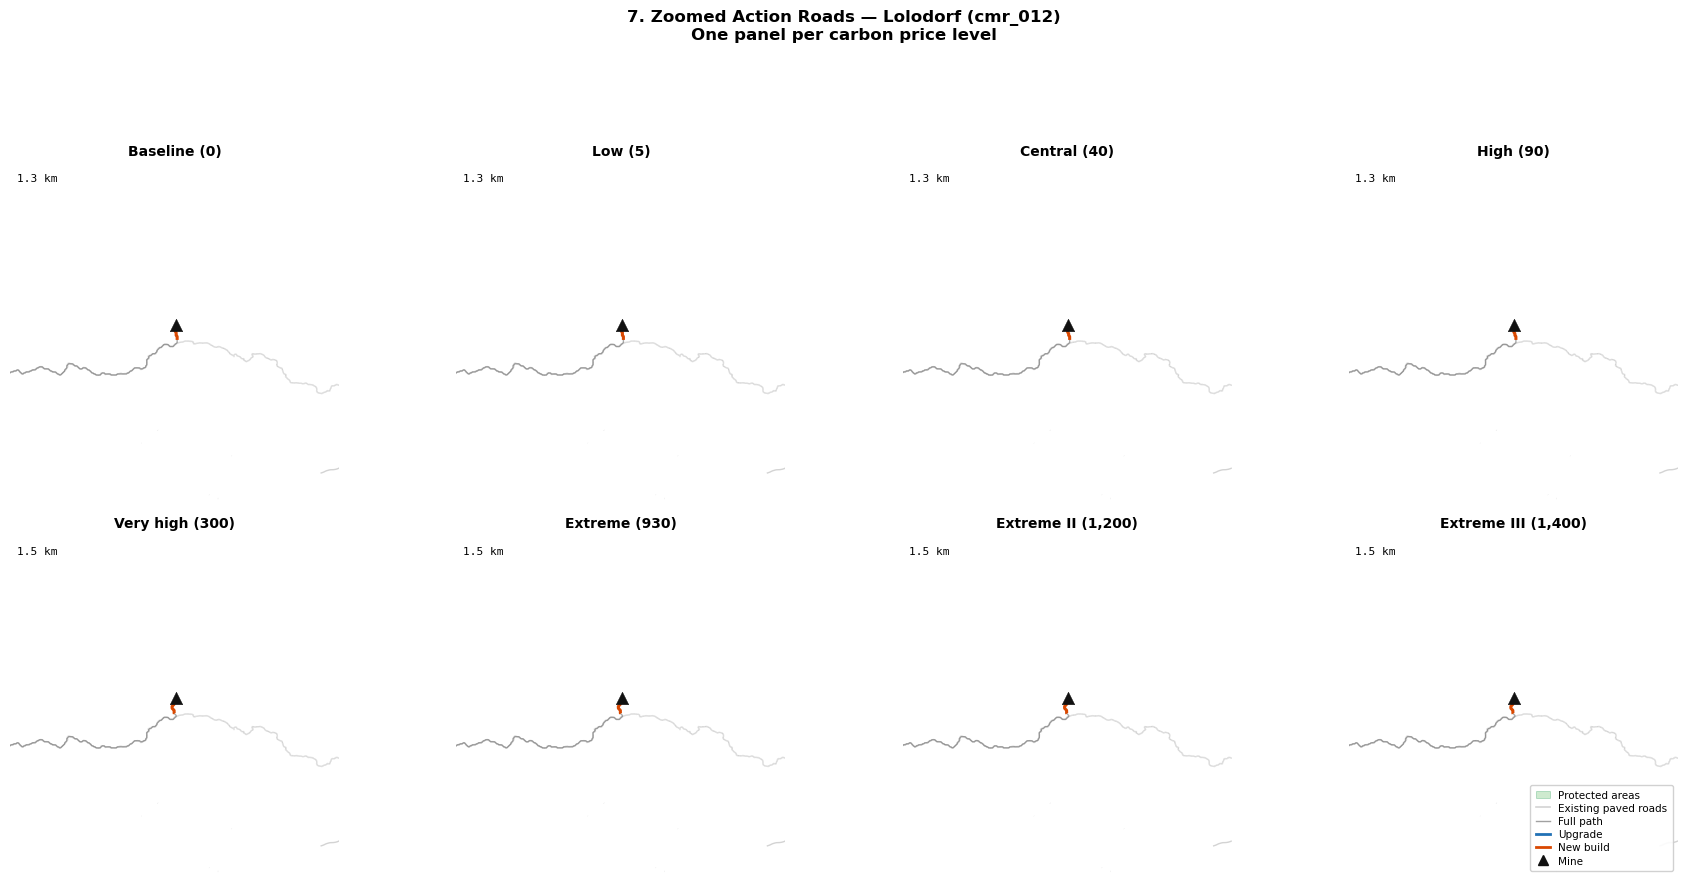

Saved: fig7_zoom_cmr_025.png


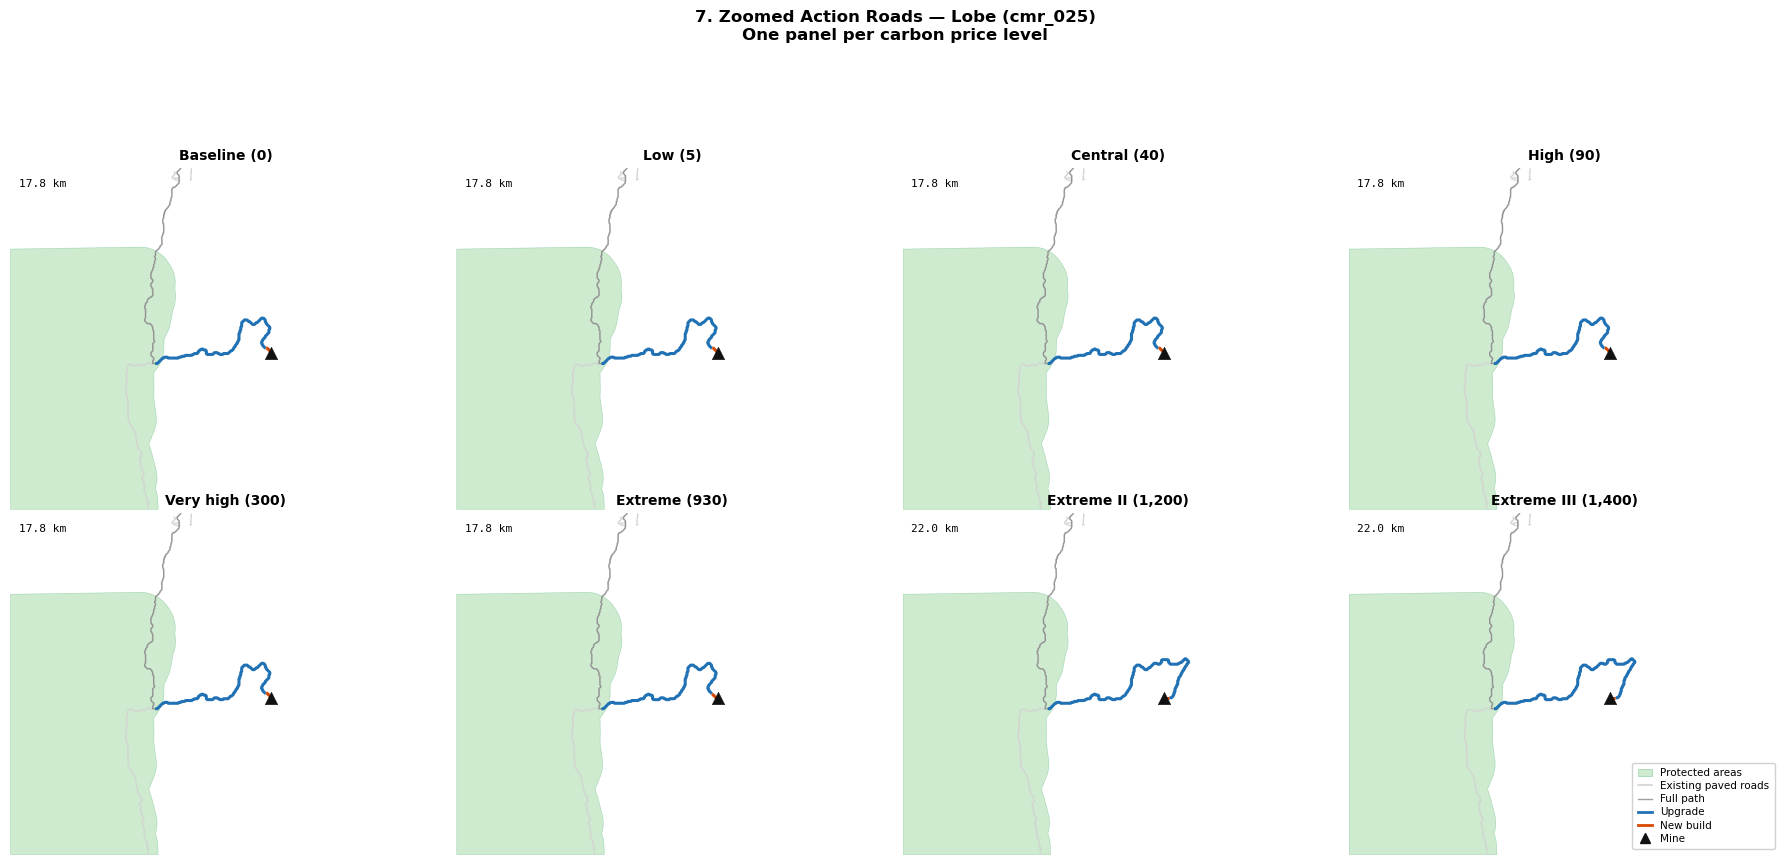

Saved: fig7_zoom_cmr_011.png


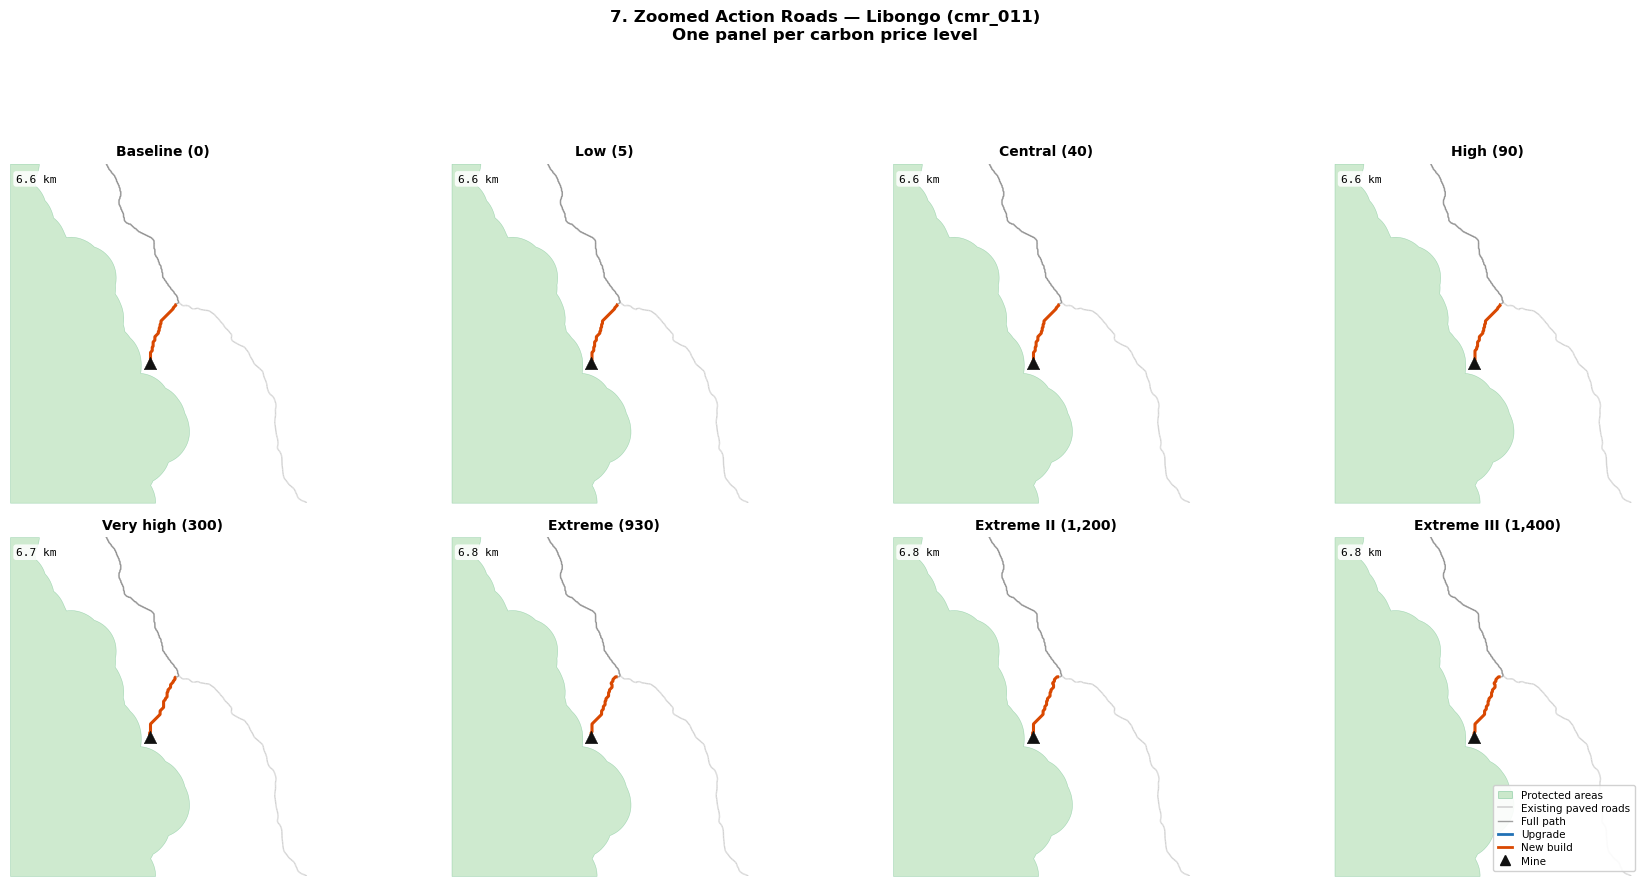

In [32]:
from shapely.geometry import box as shapely_box

SELECTED_MINE_IDS = ['cmr_016', 'cmr_009', 'cmr_013', 'cmr_014', 'cmr_012', 'cmr_025', 'cmr_011']
PAD = 0.12  # degrees padding around zoom extent

zoom_legend_handles = [
    mpatches.Patch(facecolor='#74c476', alpha=0.35, edgecolor='#2ca25f',
                   linewidth=0.6, label='Protected areas'),
    mlines.Line2D([], [], color='#d3d3d3', linewidth=1.2, label='Existing paved roads'),
    mlines.Line2D([], [], color='#444444', linewidth=1.0, alpha=0.5, label='Full path'),
    mlines.Line2D([], [], color='#2171b5', linewidth=2.0, label='Upgrade'),
    mlines.Line2D([], [], color='#d94801', linewidth=2.0, label='New build'),
    mlines.Line2D([], [], color='#111111', marker='^', markersize=7,
                  linestyle='None', label='Mine'),
]

for mine_id in SELECTED_MINE_IDS:
    # ── Compute zoom extent from all action-road segments for this mine ──────
    bounds_list = []
    for friction in FRICTION_ORDER:
        gdf = action_gdfs.get(friction)
        if gdf is not None:
            seg = gdf[gdf['mine_id'] == mine_id]
            if not seg.empty:
                bounds_list.append(seg.total_bounds)  # [minx, miny, maxx, maxy]

    mine_row = mines[mines['ID'] == mine_id]
    if bounds_list:
        all_b = np.array(bounds_list)
        zoom_minx = all_b[:, 0].min() - PAD
        zoom_miny = all_b[:, 1].min() - PAD
        zoom_maxx = all_b[:, 2].max() + PAD
        zoom_maxy = all_b[:, 3].max() + PAD
    elif not mine_row.empty:
        lon = mine_row['LONGITUDE'].values[0]
        lat = mine_row['LATITUDE'].values[0]
        zoom_minx, zoom_maxx = lon - 0.5, lon + 0.5
        zoom_miny, zoom_maxy = lat - 0.5, lat + 0.5
    else:
        print(f'No geometry or mine location found for {mine_id}, skipping.')
        continue

    clip_box = gpd.GeoDataFrame(
        geometry=[shapely_box(zoom_minx, zoom_miny, zoom_maxx, zoom_maxy)],
        crs='EPSG:4326',
    )
    pa_clip = protected_areas.clip(clip_box)
    rd_clip = paved_roads.clip(clip_box)

    # ── Figure: 2 rows × 4 cols ───────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    mine_name = mine_row['PROP_NAME'].values[0] if (not mine_row.empty and 'PROP_NAME' in mine_row.columns) else mine_id
    fig.suptitle(
        f'7. Zoomed Action Roads — {mine_name} ({mine_id})\n'
        f'One panel per carbon price level',
        fontsize=12, fontweight='bold', y=0.98,
    )

    for idx, friction in enumerate(FRICTION_ORDER):
        r, c = divmod(idx, 4)
        ax   = axes[r][c]

        if not pa_clip.empty:
            pa_clip.plot(ax=ax, color='#74c476', alpha=0.35,
                         edgecolor='#2ca25f', linewidth=0.4, zorder=0)
        if not rd_clip.empty:
            rd_clip.plot(ax=ax, color='#d3d3d3', linewidth=1.0, zorder=1)

        # Full path for this mine
        full_path = path_gdfs.get(friction)
        if full_path is not None:
            fp_mine = full_path[full_path['mine_id'] == mine_id]
            if not fp_mine.empty:
                fp_mine.plot(ax=ax, color='#444444', linewidth=1.0,
                             alpha=0.45, zorder=2)

        # Action roads for this mine
        gdf = action_gdfs.get(friction)
        seg = gdf[gdf['mine_id'] == mine_id] if gdf is not None else gpd.GeoDataFrame()
        if not seg.empty:
            upgrades   = seg[seg['action_needed'] == 'upgrade']
            new_builds = seg[seg['action_needed'] == 'build']
            if not upgrades.empty:
                upgrades.plot(ax=ax, color='#2171b5', linewidth=2.2, zorder=3)
            if not new_builds.empty:
                new_builds.plot(ax=ax, color='#d94801', linewidth=2.2, zorder=3)

        # Mine pin
        if not mine_row.empty:
            ax.scatter(mine_row['LONGITUDE'], mine_row['LATITUDE'],
                       marker='^', s=80, color='#111111',
                       edgecolors='#111111', linewidths=0.4, zorder=5)

        ax.set_xlim(zoom_minx, zoom_maxx)
        ax.set_ylim(zoom_miny, zoom_maxy)
        ax.set_title(FRICTION_LABELS[friction], fontweight='bold', fontsize=10)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Segment km label
        if not seg.empty and 'length_km' in seg.columns:
            seg_km = seg['length_km'].sum()
            ax.text(0.02, 0.97, f'{seg_km:.1f} km',
                    transform=ax.transAxes, fontsize=8, va='top', family='monospace',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              alpha=0.85, edgecolor='none'))

    # Legend in last panel
    axes[-1][-1].legend(handles=zoom_legend_handles, loc='lower right',
                        fontsize=7.5, framealpha=0.9,
                        handlelength=1.4, borderpad=0.5, labelspacing=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    out_fp = FIGURES_DIR / f'fig7_zoom_{mine_id}.png'
    plt.savefig(out_fp, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fp.name}')
    plt.show()